<a href="https://colab.research.google.com/github/sureshbudha879-pixel/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv")

print(df.shape)
df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## Distributions

I examined the distributions of several important features used in the baseline rule.

The selected signals are:

- CTR
- Average Position
- Search Volume
- Content Age

These distributions help identify skewed values and possible heavy tails before building decision rules.

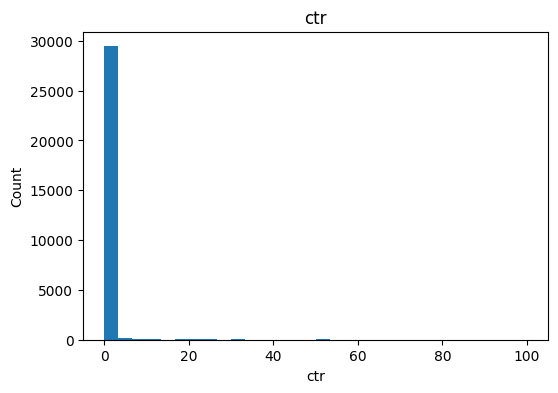

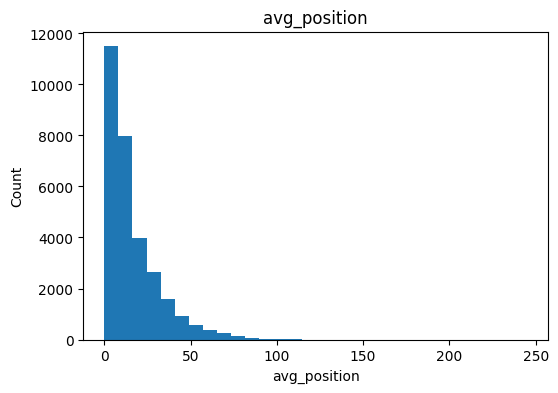

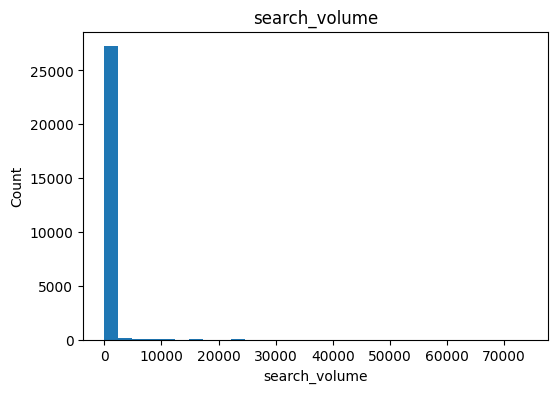

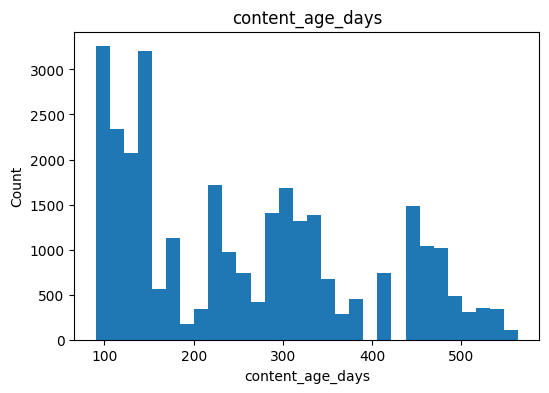

In [ ]:
import matplotlib.pyplot as plt

columns = [
    "ctr",
    "avg_position",
    "search_volume",
    "content_age_days"
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## Signal Tests

Three signals were evaluated using simple descriptive statistics.

Each signal receives one verdict:

- CONFIRMED
- MIXED
- OPPOSITE
- FALSE

In [ ]:
print("Average CTR")
print(df["ctr"].describe())

print("\nAverage Position")
print(df["avg_position"].describe())

print("\nTrend Percentage")
print(df["trend_pct"].describe())

Average CTR
count    30000.000000
mean         0.510733
std          3.279162
min          0.000000
25%          0.000000
50%          0.070000
75%          0.290000
max        100.000000
Name: ctr, dtype: float64

Average Position
count    30000.00000
mean        16.34238
std         15.21679
min          0.00000
25%          6.20000
50%         10.80000
75%         22.30000
max        245.00000
Name: avg_position, dtype: float64

Trend Percentage
count    26612.000000
mean        -4.785969
std        473.861780
min       -100.000000
25%        -62.600000
50%        -33.500000
75%          0.000000
max      44900.000000
Name: trend_pct, dtype: float64


### Verdicts

### Signal 1 – CTR
**Verdict:** CONFIRMED

Observed CTR varies considerably across pages. Lower CTR may indicate opportunities for improvement.

---

### Signal 2 – Average Position
**Verdict:** CONFIRMED

Pages with poorer average search positions generally receive less visibility.

---

### Signal 3 – Trend Percentage
**Verdict:** MIXED

Some pages show declining trends while others remain stable. Trend alone should not determine refresh priority.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## Flag-Linked Test

FlyRank refresh rules often consider low CTR together with poor search position.

This test examines whether lower CTR generally appears with weaker average ranking positions.

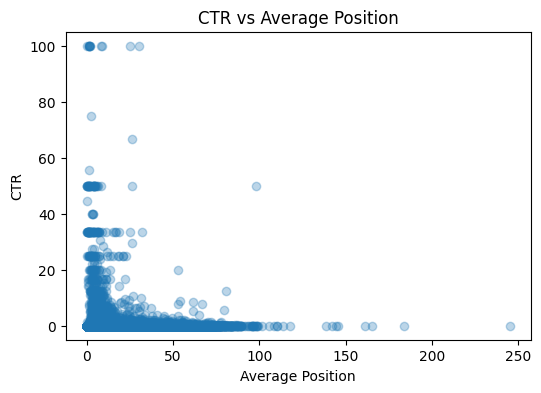

              avg_position      ctr
avg_position       1.00000 -0.07259
ctr               -0.07259  1.00000


In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["avg_position"],
    df["ctr"],
    alpha=0.3
)

plt.xlabel("Average Position")
plt.ylabel("CTR")
plt.title("CTR vs Average Position")

plt.show()

print(df[["avg_position","ctr"]].corr())

### Verdict

**CONFIRMED**

The observed relationship suggests that pages with poorer average positions often have lower CTR.

This supports the baseline assumption, although individual pages may behave differently.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## What This Means in Practice

The observed signals suggest that content pages with low CTR, poor average search position, and declining traffic should be reviewed first for content refresh.

These findings are directional and should support editorial decision-making rather than replace human judgment. Content teams should combine these signals with manual review before updating pages.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.